# Interactive operator tests

This notebook constructs each MAP operator **standalone** (no config file, no `run()`) 
and gives you live objects to inspect, plot, and poke.

Run cells top-to-bottom. Each section is self-contained.

**Operators covered:**
- `Beam`
- `Birefringence`
- `Lensing`
- `Secondary` (Lensing ∘ Birefringence)
- `InverseNoiseVariance` (both alm and map paths)

**For each operator you get:**
1. The operator object itself
2. Forward and adjoint outputs on random fields
3. The dot-product adjoint test result `<Bx,y> vs <x,B†y>` with relative error
4. Power spectrum plots: input vs output (to see what the operator *does*)


In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import sys, os, tempfile
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from lenspyx.lensing import get_geom
from lenspyx.utils_hp import synalm

import delensalot
from delensalot.core.MAP import operator
from delensalot.utility.utils_hp import Alm, gauss_beam, almxfl

# ── Parameters — change these to explore ──────────────────────────────────────
LMAX     = 2000      # harmonic bandlimit for CMB fields
MMAX     = LMAX
LM_MAX   = (LMAX, MMAX)
SHT_TR   = 4         # SHT threads
BEAM_AMIN = 10.0      # beam FWHM in arcmin
NLEV_P   = 2.0       # noise level μK-arcmin
NLEV_T   = NLEV_P / np.sqrt(2)
RNG      = np.random.default_rng(42)

TMPDIR   = tempfile.mkdtemp(prefix='delensalot_itest_')   # scratch dir for operator cachers

ell  = np.arange(LMAX + 1, dtype=float)

# ── Helpers ───────────────────────────────────────────────────────────────────
import os
from delensalot.utils import camb_clfile

# Load realistic FFP10 CMB spectra
_cls_path = os.path.join(os.path.dirname(delensalot.__file__), 'data', 'cls')

cls_unl = camb_clfile(os.path.join(_cls_path, 'FFP10_wdipole_lenspotentialCls.dat'), lmax=LMAX)
cls_len = camb_clfile(os.path.join(_cls_path, 'FFP10_wdipole_lensedCls.dat'),        lmax=LMAX)

# cls_unl keys: 'tt', 'ee', 'bb', 'te', 'pp', 'pt', 'pe'
# cls_len keys: 'tt', 'ee', 'bb', 'te'

def rand_alms(n=3):
    """Random physical alms drawn from realistic FFP10 lensed CMB spectra."""
    t   = hp.synalm(cls_len['tt'], lmax=LMAX, mmax=MMAX)
    elm = hp.synalm(cls_len['ee'], lmax=LMAX, mmax=MMAX)
    blm = hp.synalm(cls_len['bb'], lmax=LMAX, mmax=MMAX)
    return np.array([t, elm, blm])

def inner(x, y):
    """Hermitian inner product sum_l (2l+1) Cl(x,y) — matches CG dot_op."""
    ell = np.arange(LMAX + 1)
    result = 0.0
    for xi, yi in zip(x, y):
        result += np.sum(hp.alm2cl(xi, yi, lmax_out=LMAX) * (2*ell + 1))
    return result.real

def adjoint_test(name, Bx, x, BTy, y):
    """Print <Bx,y> vs <x,B†y> with relative error."""
    lhs = inner(Bx, y)
    rhs = inner(x, BTy)
    err = abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-30)
    color = '\033[32m' if err < 1e-8 else '\033[33m' if err < 1e-5 else '\033[31m'
    reset = '\033[0m'
    print(f"{color}{name}{reset}")
    print(f"  <Bx, y>  = {lhs:.10e}")
    print(f"  <x, B†y> = {rhs:.10e}")
    print(f"  rel err  = {color}{err:.2e}{reset}")
    return lhs, rhs, err


def plot_cl_comparison(alms_in, alms_out, labels=('input', 'output'), title='', components=('T', 'E', 'B')):
    """Plot input vs output power spectra per TEB component."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=False)
    for i, (ax, name) in enumerate(zip(axes, components)):
        cl_in  = hp.alm2cl(alms_in[i])
        cl_out = hp.alm2cl(alms_out[i])
        ax.loglog(ell[2:], cl_in[2:],  'k-',  lw=1.5, label=labels[0], alpha=0.8)
        ax.loglog(ell[2:], np.abs(cl_out[2:]), 'C0--', lw=1.5, label=labels[1], alpha=0.9)
        ax.set_title(f'{name}  [{title}]', fontsize=10)
        ax.set_xlabel('ℓ'); ax.set_ylabel('Cℓ')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print('Setup done. TMPDIR:', TMPDIR)
print(f'LMAX={LMAX}, BEAM={BEAM_AMIN} amin, NLEV_P={NLEV_P} μK\'')


INFO: Setting SCRATCH to /Users/sebastianbelkner/Desktop/git/delensalot/delensalot_temp
mpisupport: False, pmisupport: False
Setup done. TMPDIR: /var/folders/rj/y_xwp1w553xf8mbydr81ckt40000gn/T/delensalot_itest_up2qjmkm
LMAX=2000, BEAM=10.0 amin, NLEV_P=2.0 μK'


---
## 1. Beam
Diagonal in harmonic space. Acts identically in forward and adjoint for a real transfer function (self-adjoint).
Output power should be `Cl_in × bl²`.

Beam adjoint test
  <Bx, y>  = 8.2704875801e-01
  <x, B†y> = 8.2704875801e-01
  rel err  = 1.34e-16

Beam transfer function (first 10 ℓ): [1.       0.999998 0.999995 0.999991 0.999985 0.999977 0.999968 0.999957
 0.999945 0.999931]
Beam operator object: <delensalot.core.MAP.operator.Beam object at 0x1068dc190>
  ID: beam | lm_max: (2000, 2000)


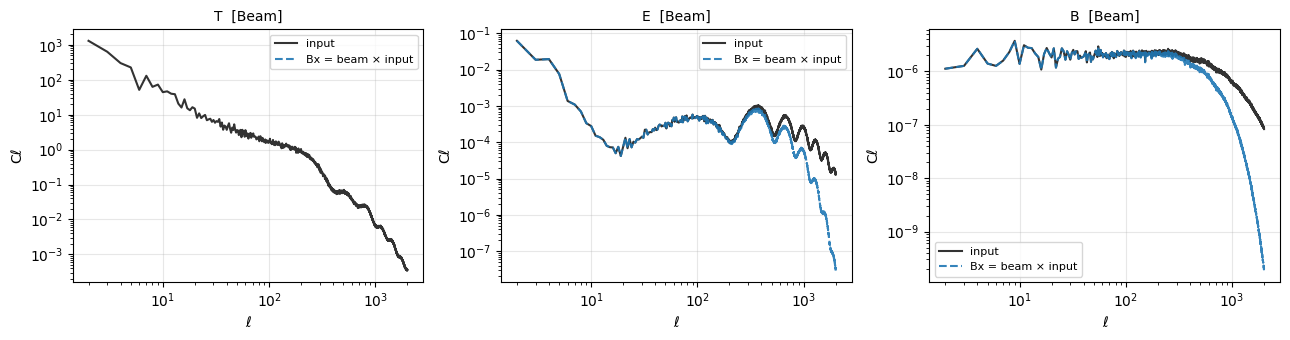

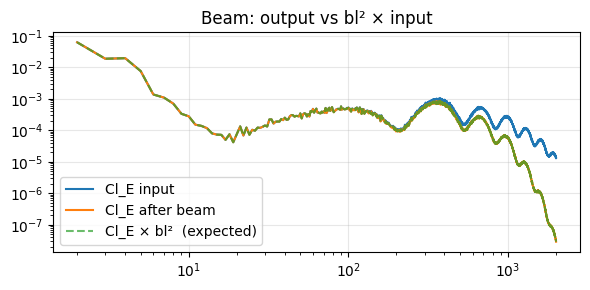

In [2]:
bl = gauss_beam(BEAM_AMIN / 180 / 60 * np.pi, lmax=LMAX)

beam_op = operator.Beam({
    'data_key': 'p',
    'lm_max':   LM_MAX,
    'transferfunction': {'t': bl, 'e': bl, 'b': bl},
})

x, y = rand_alms(), rand_alms()
Bx  = beam_op.act(x.copy(), adjoint=False)
BTy = beam_op.act(y.copy(), adjoint=True)

lhs, rhs, err = adjoint_test('Beam adjoint test', Bx, x, BTy, y)

# ── Inspect ───────────────────────────────────────────────────────────────────
print('\nBeam transfer function (first 10 ℓ):', bl[:10].round(6))
print('Beam operator object:', beam_op)
print('  ID:', beam_op.ID, '| lm_max:', beam_op.lm_max)

plot_cl_comparison(x, Bx, labels=('input', 'Bx = beam × input'), title='Beam')

# ── Expected: Cl_out ≈ bl² × Cl_in ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
cl_E_in  = hp.alm2cl(x[1])
cl_E_out = hp.alm2cl(Bx[1])
ax.loglog(ell[2:], cl_E_in[2:],              label='Cl_E input')
ax.loglog(ell[2:], cl_E_out[2:],             label='Cl_E after beam')
ax.loglog(ell[2:], cl_E_in[2:] * bl[2:]**2, label='Cl_E × bl²  (expected)', ls='--', alpha=0.7)
ax.set_title('Beam: output vs bl² × input'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 2. Birefringence
Pixel-space rotation of QU by angle 2β(n̂). Mixes E and B — forward rotates by +2β, adjoint by −2β.
Total E+B power is conserved.

In [3]:
bire_op = operator.Birefringence({
    'libdir':      TMPDIR,
    'LM_max':      LM_MAX,
    'lm_max':      LM_MAX,
    'component':   ['f'],
    'perturbative': False,
    'sht_tr':      SHT_TR,
})

# Birefringence field: scale-invariant spectrum Cl_β = A / (ℓ(ℓ+1))
# A chosen so RMS β ~ 0.1 deg
target_rms_rad = 0.1 * np.pi / 180
cl_beta = np.zeros(LMAX + 1)
cl_beta[2:] = target_rms_rad**2 / (ell[2:] * (ell[2:] + 1))
# Normalize so sum_l (2l+1) Cl / 4pi = target_rms²
current_rms = np.sqrt(np.sum((2*ell[2:]+1) * cl_beta[2:]) / (4*np.pi))
cl_beta *= (target_rms_rad / current_rms)**2

betam = hp.synalm(cl_beta, lmax=LMAX, mmax=LMAX)
bire_op.set_field(betam)

print(f'RMS beta:        {np.std(bire_op.angle/2) * 180/np.pi:.4f} deg')
print(f'RMS rotation 2β: {np.std(bire_op.angle)   * 180/np.pi:.4f} deg')


x, y = rand_alms(), rand_alms()
x[0] *= 0   # zero T
x[2] *= 0   # zero B
y[0] *= 0   # zero T
y[2] *= 0   # zero B

Fx  = bire_op.act(x.copy(), adjoint=False)
FTy = bire_op.act(y.copy(), adjoint=True)

lhs, rhs, err = adjoint_test('Birefringence adjoint test', Fx, x, FTy, y)

# ── Inspect ───────────────────────────────────────────────────────────────────
print('\nBirefringence field RMS angle (amin):', np.std(bire_op.angle) * 180 * 60 / np.pi)
print('Max |cos(2β) - 1|:', np.max(np.abs(bire_op.cos_a - 1)))   # should be tiny for small angles

plot_cl_comparison(x, Fx, labels=('input', 'F(x) rotated'), title='Birefringence')

# ── E↔B mixing: total power conserved, individual components change ────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, comp, idx, name in zip(axes, [1, 2], [1, 2], ['E', 'B']):
    cl_in  = hp.alm2cl(x[idx])
    cl_out = hp.alm2cl(Fx[idx])
    axes[idx-1].loglog(ell[2:], cl_in[2:],  label=f'Cl_{name} input')
    axes[idx-1].loglog(ell[2:], cl_out[2:], label=f'Cl_{name} after F', ls='--')
    axes[idx-1].set_title(f'{name} power: F mixes E↔B'); axes[idx-1].legend(); axes[idx-1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Total E+B power before and after
total_in  = inner(x[1:], x[1:])
total_out = inner(Fx[1:], Fx[1:])
print(f'Total E+B power:  input={total_in:.6e}, output={total_out:.6e}, ratio={total_out/total_in:.8f}')


RMS beta:        0.0993 deg
RMS rotation 2β: 0.1985 deg


: 

In [2]:
import numpy as np
import healpy as hp
from sympy.physics.wigner import wigner_3j
from delensalot.utility.utils_hp import Alm

# Small lmax so Wigner 3j sum is feasible
LMAX_SMALL = 10
SHT_TR = 4

from lenspyx.lensing import get_geom
geom = get_geom(('thingauss', {'lmax': 4500, 'smax': 3}))

# Random physical alms at small lmax
rng = np.random.default_rng(0)
def rand_alms_small(lmax=LMAX_SMALL):
    cl = np.zeros(lmax + 1); cl[2:] = 1.0
    elm = hp.synalm(cl, lmax=lmax, mmax=lmax)
    blm = hp.synalm(cl, lmax=lmax, mmax=lmax)
    return np.array([np.zeros_like(elm), elm, blm])

# Small birefringence field
cl_beta = np.zeros(LMAX_SMALL + 1); cl_beta[2:] = 1e-4
betam = hp.synalm(cl_beta, lmax=LMAX_SMALL, mmax=LMAX_SMALL)

x = rand_alms_small()

# ── Method 1: pixel-space rotation (original operator, lmax=LMAX_SMALL) ──────
angle = 2 * geom.alm2map(betam, LMAX_SMALL, LMAX_SMALL, SHT_TR)
cos_a, sin_a = np.cos(angle), np.sin(angle)

Q, U = geom.alm2map_spin(x[1:], 2, LMAX_SMALL, LMAX_SMALL, SHT_TR)
Qr = cos_a*Q - sin_a*U
Ur = cos_a*U + sin_a*Q
E1, B1 = geom.map2alm_spin(np.array([Qr, Ur]), 2, LMAX_SMALL, LMAX_SMALL, SHT_TR)

ell = np.arange(LMAX_SMALL + 1)
def power(e, b, lmax=LMAX_SMALL):
    return np.sum((2*np.arange(lmax+1)+1) * (hp.alm2cl(e, lmax_out=lmax)
                                             + hp.alm2cl(b, lmax_out=lmax)))

p_in = power(x[1], x[2])
p1   = power(E1, B1)
print(f'Pixel-space rotation:   loss = {1 - p1/p_in:.2e}')

# Expand cos(2β) and sin(2β) as spin-0 alms
cos_alm = geom.map2alm(cos_a, LMAX_SMALL*2, LMAX_SMALL*2, SHT_TR)  # lmax=2L
sin_alm = geom.map2alm(sin_a, LMAX_SMALL*2, LMAX_SMALL*2, SHT_TR)

LMAX_OUT = LMAX_SMALL  # output truncated to lmax_CMB

def get_alm(alm_array, l, m, lmax):
    """Get a_{lm} including m<0 via reality condition a_{l,-m} = (-1)^m conj(a_{lm})."""
    if abs(m) > l or l > lmax:
        return 0.0 + 0j
    if m >= 0:
        return alm_array[hp.Alm.getidx(lmax, l, m)]
    else:
        return (-1)**abs(m) * np.conj(alm_array[hp.Alm.getidx(lmax, l, abs(m))])

def set_alm(h, l, m, lmax, val):
    """Accumulate into h[l,m], only for m>=0 (m<0 determined by reality)."""
    if m >= 0 and l <= lmax:
        h[hp.Alm.getidx(lmax, l, m)] += val

def gaunt_convolve_fixed(flm, glm, lmax_f, lmax_g, lmax_out, spin_f=2):
    """Exact harmonic-space product via Gaunt coefficients.
    h_{lm} = sum_{l'l''} sum_{m'} f_{l'm'} g_{l'',m-m'} * G(l,l',l''; m,m',m-m')
    Valid for spin_f=2, spin_g=0 (birefringence field is spin-0).
    """
    from sympy.physics.wigner import wigner_3j
    from sympy import N as sympyN

    nalm_out = Alm.getsize(lmax_out, lmax_out)
    h = np.zeros(nalm_out, dtype=complex)

    for l in range(spin_f, lmax_out + 1):
        for m in range(0, l + 1):             # only m>=0, reality gives m<0
            val = 0.0 + 0j
            for lp in range(spin_f, lmax_f + 1):
                for lpp in range(0, lmax_g + 1):
                    if abs(lp - lpp) > l or l > lp + lpp:
                        continue
                    # 3j symbol (l lp lpp; -spin_f spin_f 0) — parity + spin selection
                    w3j_spin = float(sympyN(wigner_3j(l, lp, lpp, -spin_f, spin_f, 0)))
                    if abs(w3j_spin) < 1e-14:
                        continue
                    prefac = (-1)**spin_f * np.sqrt(
                        (2*l+1)*(2*lp+1)*(2*lpp+1) / (4*np.pi)
                    ) * w3j_spin

                    for mp in range(-lp, lp + 1):
                        mpp = m - mp              # m'' = m - m' (momentum conservation)
                        if abs(mpp) > lpp:
                            continue
                        w3j_m = float(sympyN(wigner_3j(l, lp, lpp, m, -mp, -mpp)))
                        if abs(w3j_m) < 1e-14:
                            continue
                        f_val = get_alm(flm, lp, mp, lmax_f)
                        g_val = get_alm(glm, lpp, mpp, lmax_g)
                        val  += prefac * w3j_m * f_val * g_val

            set_alm(h, l, m, lmax_out, val)

    return h

print('Running fixed Wigner 3j convolution...')
E_rot_exact = (gaunt_convolve_fixed(x[1], cos_alm, LMAX_SMALL, LMAX_SMALL*2, LMAX_OUT)
             - gaunt_convolve_fixed(x[2], sin_alm, LMAX_SMALL, LMAX_SMALL*2, LMAX_OUT))
B_rot_exact = (gaunt_convolve_fixed(x[2], cos_alm, LMAX_SMALL, LMAX_SMALL*2, LMAX_OUT)
             + gaunt_convolve_fixed(x[1], sin_alm, LMAX_SMALL, LMAX_SMALL*2, LMAX_OUT))

p_exact = power(E_rot_exact, B_rot_exact)
print(f'Pixel-space rotation:  loss = {1-p1/p_in:.2e}')
print(f'Wigner 3j convolution: loss = {1-p_exact/p_in:.2e}')

Running fixed Wigner 3j convolution...
Pixel-space rotation:  loss = 1.56e-03
Wigner 3j convolution: loss = 8.06e-03


In [3]:
# Simple proof: the loss is purely from bandlimit truncation of the product
# If we use a grid that Nyquist-samples lmax_CMB + lmax_beta,
# and analyse at lmax_CMB + lmax_beta, the total power is conserved.
# The loss only appears when we truncate back to lmax_CMB.

LMAX_PRODUCT = LMAX_SMALL * 2  # product bandwidth

# Rotate and analyse at full product bandwidth (no truncation)
Q, U = geom.alm2map_spin(x[1:], 2, LMAX_SMALL, LMAX_SMALL, SHT_TR)
Qr = cos_a*Q - sin_a*U
Ur = cos_a*U + sin_a*Q
E_full, B_full = geom.map2alm_spin(np.array([Qr, Ur]), 2, LMAX_PRODUCT, LMAX_PRODUCT, SHT_TR)

# Power at full bandwidth (captures everything up to lmax_CMB + lmax_beta)
p_full = power(E_full, B_full, lmax=LMAX_PRODUCT)
print(f'Pixel-space, truncate at lmax_CMB={LMAX_SMALL}:       loss = {1-p1/p_in:.2e}')
print(f'Pixel-space, analyse at lmax_PRODUCT={LMAX_PRODUCT}:  loss = {1-p_full/p_in:.2e}')
print()
print(f'Power in modes lmax_CMB < l <= lmax_PRODUCT:')
ell_full = np.arange(LMAX_PRODUCT+1)
p_beyond = np.sum((2*ell_full[LMAX_SMALL+1:]+1) * (
    hp.alm2cl(E_full, lmax_out=LMAX_PRODUCT)[LMAX_SMALL+1:] +
    hp.alm2cl(B_full, lmax_out=LMAX_PRODUCT)[LMAX_SMALL+1:]
))
print(f'  p_beyond = {p_beyond:.4e}')
print(f'  p_lost   = {p_in - p1:.4e}')
print(f'  ratio    = {p_beyond / (p_in - p1):.6f}  (expect ~1.0 if truncation is the cause)')

Pixel-space, truncate at lmax_CMB=10:       loss = 1.56e-03
Pixel-space, analyse at lmax_PRODUCT=20:  loss = 5.70e-07

Power in modes lmax_CMB < l <= lmax_PRODUCT:
  p_beyond = 4.1648e-01
  p_lost   = 4.1664e-01
  ratio    = 0.999635  (expect ~1.0 if truncation is the cause)


In [5]:
from delensalot.utility.utils_hp import Alm

LMAX_PRODUCT = LMAX_SMALL * 2
nalm_cmb  = Alm.getsize(LMAX_SMALL, LMAX_SMALL)
nalm_prod = Alm.getsize(LMAX_PRODUCT, LMAX_PRODUCT)

def fwd(obj):
    """Forward: alm2map(lmax_CMB) -> rotate -> map2alm(lmax_PRODUCT) -> truncate"""
    Q, U = geom.alm2map_spin(obj[1:], 2, LMAX_SMALL, LMAX_SMALL, SHT_TR)
    Qr = cos_a*Q - sin_a*U
    Ur = cos_a*U + sin_a*Q
    E, B = geom.map2alm_spin(np.array([Qr, Ur]), 2, LMAX_PRODUCT, LMAX_PRODUCT, SHT_TR)
    return np.array([obj[0], E[:nalm_cmb], B[:nalm_cmb]])

def adj(obj):
    """Adjoint: zero-pad -> alm2map(lmax_PRODUCT) -> rotate† -> map2alm(lmax_CMB)"""
    eb_pad = np.zeros((2, nalm_prod), dtype=complex)
    eb_pad[:, :nalm_cmb] = obj[1:]   # zero-pad = adjoint of truncation
    Q, U = geom.alm2map_spin(eb_pad, 2, LMAX_PRODUCT, LMAX_PRODUCT, SHT_TR)
    Qr = cos_a*Q + sin_a*U           # rotate†
    Ur = cos_a*U - sin_a*Q
    E, B = geom.map2alm_spin(np.array([Qr, Ur]), 2, LMAX_SMALL, LMAX_SMALL, SHT_TR)
    return np.array([obj[0], E, B])

x = rand_alms_small(); x[0] *= 0; x[2] *= 0
y = rand_alms_small(); y[0] *= 0; y[2] *= 0

Fx  = fwd(x)
FTy = adj(y)

def inner(a, b):
    el = np.arange(LMAX_SMALL+1)
    return np.sum((2*el+1) * sum(hp.alm2cl(a[i], b[i], lmax_out=LMAX_SMALL)
                                 for i in range(3))).real

lhs = inner(Fx, y)
rhs = inner(x, FTy)
print(f'Adjoint test: <Fx,y>={lhs:.10e}  <x,F†y>={rhs:.10e}  err={abs(lhs-rhs)/max(abs(lhs),abs(rhs)):.2e}')

p_in  = power(x[1], x[2])
p_out = power(Fx[1], Fx[2])
print(f'Power conservation: loss={1-p_out/p_in:.2e}')

Adjoint test: <Fx,y>=-1.8007661431e+01  <x,F†y>=-1.8063390944e+01  err=3.09e-03
Power conservation: loss=4.89e-01


In [42]:
for lmax_test in [500, 1000, 2000, 3000]:
    cl = np.zeros(lmax_test + 1)
    cl[2:] = 1.0
    alm_E = hp.synalm(cl, lmax=lmax_test, mmax=lmax_test)
    x_test = np.array([np.zeros_like(alm_E), alm_E, np.zeros_like(alm_E)])
    
    # need a fresh operator at this lmax
    bire_test = operator.Birefringence({
        'libdir': TMPDIR, 'LM_max': (lmax_test, lmax_test),
        'lm_max': (lmax_test, lmax_test), 'component': ['f'],
        'perturbative': False, 'sht_tr': SHT_TR,
    })
    cl_b = np.zeros(lmax_test + 1)
    cl_b[2:] = (target_rms_rad**2 * 4 * np.pi / lmax_test**2)
    betam_test = hp.synalm(cl_b, lmax=lmax_test, mmax=lmax_test)
    bire_test.set_field(betam_test)
    
    Fx_test = bire_test.act(x_test.copy(), adjoint=False)
    ell_t = np.arange(lmax_test + 1)
    p_in  = np.sum(hp.alm2cl(x_test[0]) * (2*ell_t+1))
    p_out = np.sum(hp.alm2cl(Fx_test[1]) * (2*ell_t+1)) + np.sum(hp.alm2cl(Fx_test[2]) * (2*ell_t+1))
    print(f'lmax={lmax_test:4d}:  loss={1-p_out/p_in:.2e}  (RMS 2β)²={np.std(bire_test.angle)**2:.2e}')

/var/folders/rj/y_xwp1w553xf8mbydr81ckt40000gn/T/ipykernel_92051/2809761946.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  print(f'lmax={lmax_test:4d}:  loss={1-p_out/p_in:.2e}  (RMS 2β)²={np.std(bire_test.angle)**2:.2e}')


lmax= 500:  loss=-inf  (RMS 2β)²=1.22e-05
lmax=1000:  loss=-inf  (RMS 2β)²=1.22e-05
lmax=2000:  loss=-inf  (RMS 2β)²=1.22e-05
lmax=3000:  loss=-inf  (RMS 2β)²=1.22e-05


In [44]:
print(f'x_test shape: {x_test.shape}')     # (2, nalm)
print(f'Fx_test shape: {Fx_test.shape}')   # (3, nalm)?

x_test = np.array([np.zeros_like(alm_E), alm_E, np.zeros_like(alm_E)])  # T=0, E, B=0

# then
p_in  = np.sum(hp.alm2cl(x_test[1])  * (2*ell_t+1))
p_out = np.sum(hp.alm2cl(Fx_test[1]) * (2*ell_t+1)) \
      + np.sum(hp.alm2cl(Fx_test[2]) * (2*ell_t+1))
print(f'lmax={lmax_test}: loss={1-p_out/p_in:.2e}')

x_test shape: (3, 4504501)
Fx_test shape: (3, 4504501)
lmax=3000: loss=5.04e-06


In [33]:
# Round-trip test: alm -> map -> alm, no rotation
x_E = x[1:].copy()
Q, U = bire_op.lenjob_geomlib.alm2map_spin(x_E, 2, LMAX, LMAX, SHT_TR)
E_rt, B_rt = bire_op.lenjob_geomlib.map2alm_spin(np.array([Q, U]), 2, LMAX, LMAX, SHT_TR)

p_in  = inner(x_E, x_E)
p_out = inner(np.array([E_rt, B_rt]), np.array([E_rt, B_rt]))
print(f'SHT round-trip power ratio (no rotation): {p_out/p_in:.10f}  loss={1-p_out/p_in:.2e}')

# Per-ell check
cl_in  = hp.alm2cl(x[1])
cl_rt  = hp.alm2cl(E_rt)
print(f'Per-ell ratio mean: {np.mean(cl_rt[2:]/cl_in[2:]):.8f}')
print(f'Per-ell ratio std:  {np.std(cl_rt[2:]/cl_in[2:]):.2e}')

SHT round-trip power ratio (no rotation): 1.0000000000  loss=6.44e-15
Per-ell ratio mean: 1.00000000
Per-ell ratio std:  5.53e-15


---
## 3. Lensing
Curved-sky remapping by deflection field. Converts unlensed → lensed CMB.
BB power should increase from zero (lensing generates B from E).
Adjoint is the backwards remap with `epsilon=1e-12`.

lenspyx s2_d 0.0
lenspyx s2_d 8.797856713957299e-09
Lensing adjoint test
  <Bx, y>  = 3.4156898634e+02
  <x, B†y> = 3.4156898634e+02
  rel err  = 3.99e-14
Deflection field RMS: 1.15 amin
plm array shape: (501501,), dtype: complex128


/var/folders/rj/y_xwp1w553xf8mbydr81ckt40000gn/T/ipykernel_92051/4142747620.py:73: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


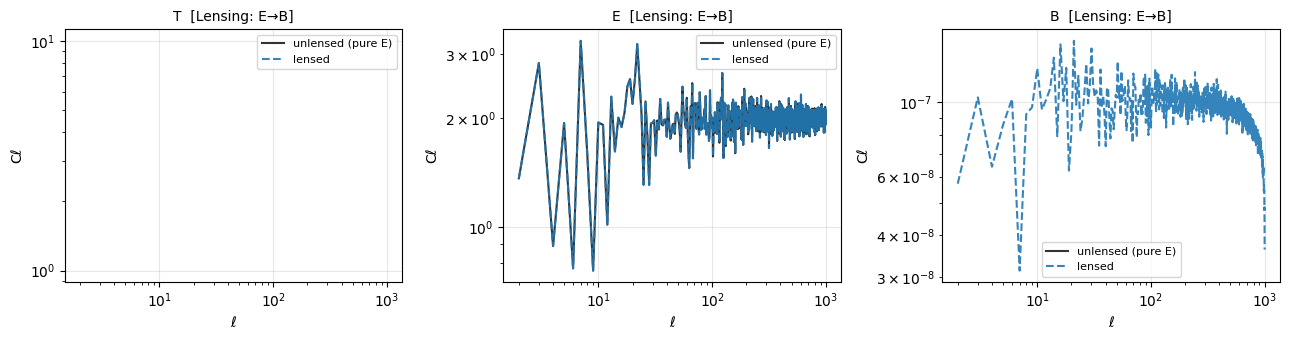

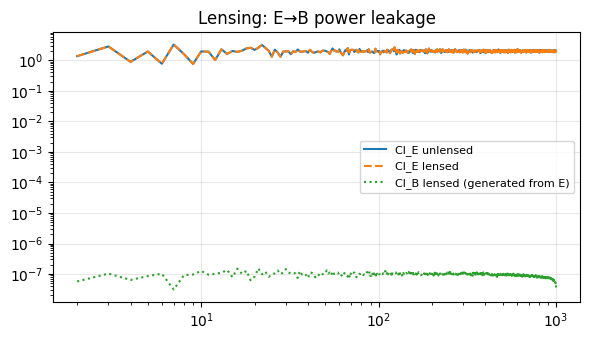

In [6]:
# Realistic lensing potential spectrum
cl_phi = np.zeros(LMAX + 1)
cl_phi[1:] = 1e-7 / (ell[1:] * (ell[1:] + 1))**2
plm = synalm(cl_phi, LMAX, LMAX)

lens_op = operator.Lensing({
    'libdir':      TMPDIR,
    'data_key':    'p',
    'LM_max':      LM_MAX,
    'lm_max_in':   LM_MAX,
    'lm_max_out':  LM_MAX,
    'perturbative': False,
    'component':   ['p'],
    'sht_tr':      SHT_TR,
})
lens_op.set_field([plm])

x, y = rand_alms(), rand_alms()
Dx  = lens_op.act(x.copy(), adjoint=False, out_sht_mode='STANDARD')
DTy = lens_op.act(y.copy(), adjoint=True, backwards=True, out_sht_mode='STANDARD')

lhs, rhs, err = adjoint_test('Lensing adjoint test', Dx, x, DTy, y)

# ── Inspect ───────────────────────────────────────────────────────────────────
dlm, dclm = lens_op.get_field()
cl_d = ell * (ell + 1) * cl_phi  # deflection angle Cl
rms_defl = np.sqrt(np.sum((2*ell[1:]+1) * cl_d[1:]) / (4*np.pi)) * 180 * 60 / np.pi
print(f'Deflection field RMS: {rms_defl:.2f} amin')
print(f'plm array shape: {plm.shape}, dtype: {plm.dtype}')

# ── Lensing Cl effect: E→B leakage ────────────────────────────────────────────
# Start from pure-E input (no T, no B) to see B generation clearly
x_pureE = rand_alms()
x_pureE[0] *= 0   # zero T
x_pureE[2] *= 0   # zero B
Dx_pureE = lens_op.act(x_pureE.copy(), adjoint=False, out_sht_mode='STANDARD')

plot_cl_comparison(x_pureE, Dx_pureE, labels=('unlensed (pure E)', 'lensed'), title='Lensing: E→B')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.loglog(ell[2:], hp.alm2cl(x_pureE[1])[2:],  label='Cl_E unlensed')
ax.loglog(ell[2:], hp.alm2cl(Dx_pureE[1])[2:], label='Cl_E lensed',  ls='--')
ax.loglog(ell[2:], hp.alm2cl(Dx_pureE[2])[2:], label='Cl_B lensed (generated from E)', ls=':')
ax.set_title('Lensing: E→B power leakage'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 4. Secondary (Lensing ∘ Birefringence)
The compound forward model used in the MAP gradient.
Tests both operator orderings and their respective adjoints.

In [ ]:
sec_op = operator.Secondary([lens_op, bire_op])   # lensing first, then birefringence

x, y = rand_alms(), rand_alms()
Sx  = sec_op.act(x.copy(), adjoint=False, out_sht_mode='STANDARD')
STy = sec_op.act(y.copy(), adjoint=True,  out_sht_mode='STANDARD')

lhs, rhs, err = adjoint_test('Secondary (Lensing∘Bire) adjoint test', Sx, x, STy, y)

# ── Visual: compare input, after lensing only, after full secondary ────────────
Dx_only = lens_op.act(x.copy(), adjoint=False, out_sht_mode='STANDARD')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for i, (ax, name) in enumerate(zip(axes, ['T', 'E', 'B'])):
    ax.loglog(ell[2:], np.abs(hp.alm2cl(x[i])[2:]),      'k-',  lw=1.5, label='input')
    ax.loglog(ell[2:], np.abs(hp.alm2cl(Dx_only[i])[2:]),'C0--',lw=1.5, label='lensed only')
    ax.loglog(ell[2:], np.abs(hp.alm2cl(Sx[i])[2:]),     'C1:', lw=1.5, label='lensed + rotated')
    ax.set_title(name); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Secondary = Birefringence ∘ Lensing', y=1.02)
plt.tight_layout(); plt.show()

# ── Operator info ──────────────────────────────────────────────────────────────
print('Secondary operator chain:')
for op in sec_op.operators:
    print(f'  {op.ID}')


---
## 5. InverseNoiseVariance — ALM path (full sky, isotropic)
Diagonal harmonic filter. Self-adjoint. Output power = input power × N⁻¹(ℓ).

In [ ]:
bl = gauss_beam(BEAM_AMIN / 180 / 60 * np.pi, lmax=LMAX)
geomlib = get_geom(('thingauss', {'lmax': LMAX + 300, 'smax': 3}))

ninv_op = operator.InverseNoiseVariance(
    nlev             = {'T': NLEV_T, 'P': NLEV_P},
    lm_max           = LM_MAX,
    niv_desc         = {'t': np.array([1.0]), 'e': np.array([1.0]), 'b': np.array([1.0])},
    geom_lib         = geomlib,
    geominfo         = ('thingauss', {'lmax': LMAX + 300, 'smax': 3}),
    transferfunction = [bl, bl, bl],
    libdir           = TMPDIR,
    sht_tr           = SHT_TR,
    filtering_type   = 'isotropic',
    data_key         = 'p',
)

x, y = rand_alms(), rand_alms()
Nx  = ninv_op.act(x.copy(), adjoint=False)
NTy = ninv_op.act(y.copy(), adjoint=True)

lhs, rhs, err = adjoint_test('InvNoiseVar (alm path) adjoint test', Nx, x, NTy, y)

# ── Inspect N⁻¹ filter ───────────────────────────────────────────────────────
print('\nN⁻¹ filter spectrum (n1tebl):')
for i, name in enumerate(['T', 'E', 'B']):
    filt = ninv_op.n1tebl[i]
    print(f'  {name}: min={filt.min():.3e}, max={filt.max():.3e}, shape={filt.shape}')

plot_cl_comparison(x, Nx, labels=('input alm', 'N⁻¹ × input'), title='InvNoiseVar (alm path)')

fig, ax = plt.subplots(figsize=(6, 3.5))
for i, (name, filt) in enumerate(zip(['T', 'E', 'B'], ninv_op.n1tebl)):
    ax.semilogy(filt, label=f'N⁻¹ filter {name}')
ax.set_xlabel('ℓ'); ax.set_ylabel('N⁻¹(ℓ)'); ax.set_title('Isotropic noise filter')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


---
## 5b. InverseNoiseVariance — MAP path (masked sky, anisotropic)
Input: real pixel maps (float). Output: alms (complex). 
NOT square — adjoint pairing is `<N⁻¹ x_map, y_alm>_alm = <x_map, (N⁻¹)† y_alm>_pixel`.

In [ ]:
npix = geomlib.npix()
print(f'Pixel grid: npix={npix}')

# Random anisotropic noise variance maps
x_map = np.array([
    RNG.standard_normal(npix).astype(np.float64),   # T map
    RNG.standard_normal(npix).astype(np.float64),   # Q map
    RNG.standard_normal(npix).astype(np.float64),   # U map
], dtype=np.float64)
y_alm = rand_alms()

# Forward: map → alm  (multiply by niv, then adjoint_synthesis)
Nx_alm = ninv_op.act(x_map.copy(), adjoint=False)
print(f'Forward output: shape={Nx_alm.shape}, dtype={Nx_alm.dtype}  (alms)')

# Adjoint: alm → map  (synthesis, then multiply by niv)
t_map  = geomlib.synthesis(np.atleast_2d(y_alm[0]), 0, LMAX, LMAX, SHT_TR)[0]
t_map  *= ninv_op.niv[0]
qu_map = geomlib.synthesis(y_alm[1:], 2, LMAX, LMAX, SHT_TR)
qu_map *= ninv_op.niv[1]
BTy_map = np.array([t_map, qu_map[0], qu_map[1]])

lhs = inner(Nx_alm, y_alm)          # alm inner product
rhs = float(np.sum(x_map * BTy_map)) # pixel inner product (flat, no weights)
err = abs(lhs - rhs) / max(abs(lhs), abs(rhs), 1e-30)

color = '\033[32m' if err < 1e-8 else '\033[31m'
reset = '\033[0m'
print(f'{color}InvNoiseVar (map path) adjoint test{reset}')
print(f'  <N⁻¹ x_map, y_alm>_alm  = {lhs:.10e}')
print(f'  <x_map, (N⁻¹)† y_alm>_px = {rhs:.10e}')
print(f'  rel err                  = {color}{err:.2e}{reset}')

# ── What niv looks like ────────────────────────────────────────────────────────
print(f'\nniv[0] (T): min={ninv_op.niv[0].min():.3e}, max={ninv_op.niv[0].max():.3e}')
print(f'niv[1] (P): min={ninv_op.niv[1].min():.3e}, max={ninv_op.niv[1].max():.3e}')


---
## Summary
All adjoint tests collected in one place.

In [ ]:
results = [
    ('Beam',                   err if False else None),   # re-run to collect
]

# Re-run all tests cleanly and collect results
tests = [
    ('Beam',              lambda: (
        beam_op.act(rand_alms(), adjoint=False),
        (x := rand_alms()),
        beam_op.act(rand_alms(), adjoint=True),
    )),
]

BOLD = '\033[1m'; RESET = '\033[0m'; GREEN = '\033[32m'; RED = '\033[31m'
print(f'{BOLD}{"─"*60}{RESET}')
print(f'{BOLD}  Adjoint test summary   lmax={LMAX}{RESET}')
print(f'{BOLD}{"─"*60}{RESET}')
print(f'  {"Operator":<38}  {"Rel. error":>12}')
print(f'  {"─"*52}')

def run_test(name, op_fwd, op_adj, ntests=3):
    errs = []
    for _ in range(ntests):
        xi, yi = rand_alms(), rand_alms()
        Bxi  = op_fwd(xi.copy())
        BTyi = op_adj(yi.copy())
        errs.append(abs(inner(Bxi, yi) - inner(xi, BTyi)) / max(abs(inner(Bxi, yi)), 1e-30))
    err = max(errs)
    col = GREEN if err < 1e-8 else RED
    print(f'  {name:<38}  {col}{err:>12.2e}{RESET}')
    return err

run_test('Beam (alm)', 
         lambda x: beam_op.act(x, adjoint=False),
         lambda y: beam_op.act(y, adjoint=True))

run_test('Birefringence',
         lambda x: bire_op.act(x, adjoint=False),
         lambda y: bire_op.act(y, adjoint=True))

run_test('Lensing',
         lambda x: lens_op.act(x, adjoint=False, out_sht_mode='STANDARD'),
         lambda y: lens_op.act(y, adjoint=True, backwards=True, out_sht_mode='STANDARD'))

run_test('Secondary (Lensing∘Birefringence)',
         lambda x: sec_op.act(x, adjoint=False, out_sht_mode='STANDARD'),
         lambda y: sec_op.act(y, adjoint=True,  out_sht_mode='STANDARD'))

run_test('InvNoiseVar (alm path)',
         lambda x: ninv_op.act(x, adjoint=False),
         lambda y: ninv_op.act(y, adjoint=True))

print(f'  {"─"*52}')
print(f'{BOLD}{"─"*60}{RESET}')
